In [ ]:
# %%
# flow matching
# xt =(1-t)x0 + tx1
# v = dx/dt = x1 - x0
# Training:  arg min  E[‖X1 − X0 − v(tX1 + (1 − t)X0, t)‖2]  , with t ∼ Uniform([0, 1]).
# loss = |v_theta(xt, t) - (x1-x0)|^2 感觉真实分布很难学，不如高斯分布简单
# sampling ODE dx/dt = v @ (t=0, x0)
# xn+1 = xt + v*dt t=[0, 1] # 推理步骤变少了，20步即可生成

# %%
# Basic Math
print("hello, this is notebook")

hello, this is notebook


In [2]:
# %%
#%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_s_curve
import torch
from torch import nn
from torch.optim import AdamW, Adam
from torch.utils.data import DataLoader, TensorDataset


In [3]:
# %%
s_curve, _ = make_s_curve(10000, noise=0.1)
print(s_curve.shape)
s_curve = s_curve[:, [0, 2]]/10.0 # 只保留x和z坐标，并缩放到0-1范围内
print("shape 2D:",s_curve.shape)
# plt.scatter(s_curve[:, 0], s_curve[:, 1], s=10, color="orange")
# plt.xlabel("x")
# plt.ylabel("y")
# plt.title("S-curve")
# plt.show()
print("S曲线是若干离散点组成，看作是一种数据分布")

# %%
data = torch.from_numpy(s_curve).float()
print("dataset shape:", data.shape)

(10000, 3)
shape 2D: (10000, 2)
S曲线是若干离散点组成，看作是一种数据分布
dataset shape: torch.Size([10000, 2])


In [4]:
# 1.搭建噪声学习网络epsilon_theta
# 2. 数据学习训练 
#    loss = E[||epsilon - epsilon_theta(x_t, t)||^2]

# 可以选择2种网络架构
# （1）UNet 结构的噪声预测网络
# （2）Transformer 结构的噪声预测网络
class VelocityPredictorNet(nn.Module):
    # 此处仅为演示使用简单net结构 MLP
    def __init__(self, num_steps:int, num_units:int=128):
        super(VelocityPredictorNet, self).__init__()

        # 时间步嵌入层
        #self.embeding = nn.Embedding(num_steps, num_units)
        # 适用于浮点数
        self.embeding = nn.Sequential(
            nn.Linear(1, num_units),
            nn.SiLU(),
            nn.Linear(num_units, num_units)
        )

        # 线性层网络, 串联
        # xt 图片 + time embding
        self.linear = nn.Sequential(
                nn.Linear(2+num_units, num_units),
                nn.SiLU(),
                nn.Linear(num_units, num_units),
                nn.SiLU(),
                nn.Linear(num_units, num_units),
                nn.SiLU(),
                nn.Linear(num_units, 2)
        )

    def forward(self, xt:torch.Tensor, t:torch.Tensor) -> torch.Tensor:
        """
        xt: shape (nt, npts, dim=2)
        t: shape (nt, 1)
        返回 epsilon_theta(xt, t)，shape (nt, npts, dim=2)
        """
        
        t_embeding = self.embeding(t) # 时间步嵌入，shape (nt, num_units)
        nt, npts, dim = xt.shape
        t_embeding = t_embeding.unsqueeze(1).expand(-1, npts, -1) # (nt, ntps, num_units)
        # 拼接时间步嵌入和输入
        xt_cat =  torch.cat([xt, t_embeding], dim=-1) # shape (nt, npts, 2 + num_units)
        
        #最后一层线性层输出噪声预测 velocity_theta
        velocity_theta = self.linear(xt_cat) # 线性层 (npts, 2)
        return velocity_theta

 epoch 0/1000 mean loss:0.2646
 epoch 20/1000 mean loss:0.2804
 epoch 40/1000 mean loss:0.1075
 epoch 60/1000 mean loss:0.2198
 epoch 80/1000 mean loss:0.2136
 epoch 100/1000 mean loss:0.0920
 epoch 120/1000 mean loss:0.1655
 epoch 140/1000 mean loss:0.3005
 epoch 160/1000 mean loss:0.1479
 epoch 180/1000 mean loss:0.2740
 epoch 200/1000 mean loss:0.1201
 epoch 220/1000 mean loss:0.1777
 epoch 240/1000 mean loss:0.1871
 epoch 260/1000 mean loss:0.2452
 epoch 280/1000 mean loss:0.1168
 epoch 300/1000 mean loss:0.2285
 epoch 320/1000 mean loss:0.2189
 epoch 340/1000 mean loss:0.2571
 epoch 360/1000 mean loss:0.1554
 epoch 380/1000 mean loss:0.1935
 epoch 400/1000 mean loss:0.2440
 epoch 420/1000 mean loss:0.2432
 epoch 440/1000 mean loss:0.1482
 epoch 460/1000 mean loss:0.1493
 epoch 480/1000 mean loss:0.1748
 epoch 500/1000 mean loss:0.1522
 epoch 520/1000 mean loss:0.0938
 epoch 540/1000 mean loss:0.1084
 epoch 560/1000 mean loss:0.0958
 epoch 580/1000 mean loss:0.1034
 epoch 600/1000 

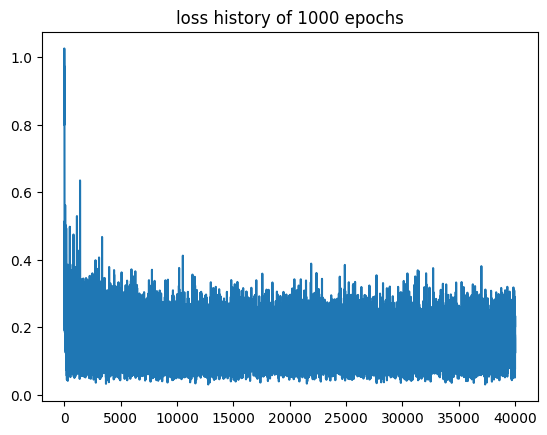

In [ ]:
# 配对数据 X0 --- X1
# 随机t=[0,1] 然后 预测 V（Xt = tX1 + (1-t)X0, t）
# loss = v -|x1-x0|
steps = 20

model = VelocityPredictorNet(steps)
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

## 非常重要epoch内循环
# 保证每个epoch都能看到所有数据，且每个batch随机抽取不同时间步t
epochs = 1000
sample_npts = 256
nt = steps
## total_ns = 10000//256 = 40
history = []
for epoch in range(epochs):
    # 训练过程中每个epoch都要遍历整个数据集
    perm = torch.randperm(data.shape[0])
    for start in range(0, perm.shape[0], sample_npts):
        # x1图像数据
        x1 = data[start:start+sample_npts] # shape (npts, dim)
        x0 = torch.randn_like(x1) # 随机
        # volocity = x1 - x0
        velocity_true = x1 - x0
        t = torch.rand(nt).unsqueeze(-1) #(nt, 1)
        x1 = x1.unsqueeze(0) # (1, npts, dim)
        x0 = x0.unsqueeze(0) # (1, npts, dim)
        text = t.unsqueeze(-1)  #(nt, 1, 1)
        xt = text*x1 + (1.0- text)*x0 # (nt, npts, dim)
        velocity_pred = model(xt, t) # (nt, ntps, dim)
        loss = torch.square((velocity_pred - velocity_true)).mean()
        #
        model.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())
    if epoch % 20 == 0:
        print(f" epoch {epoch}/{epochs} mean loss:{history[-1]:.4f}")
#

torch.save(model.state_dict(), "flow_state_dict.pt")
plt.plot(history)
plt.title(f"loss history of {epochs} epochs")
plt.show()


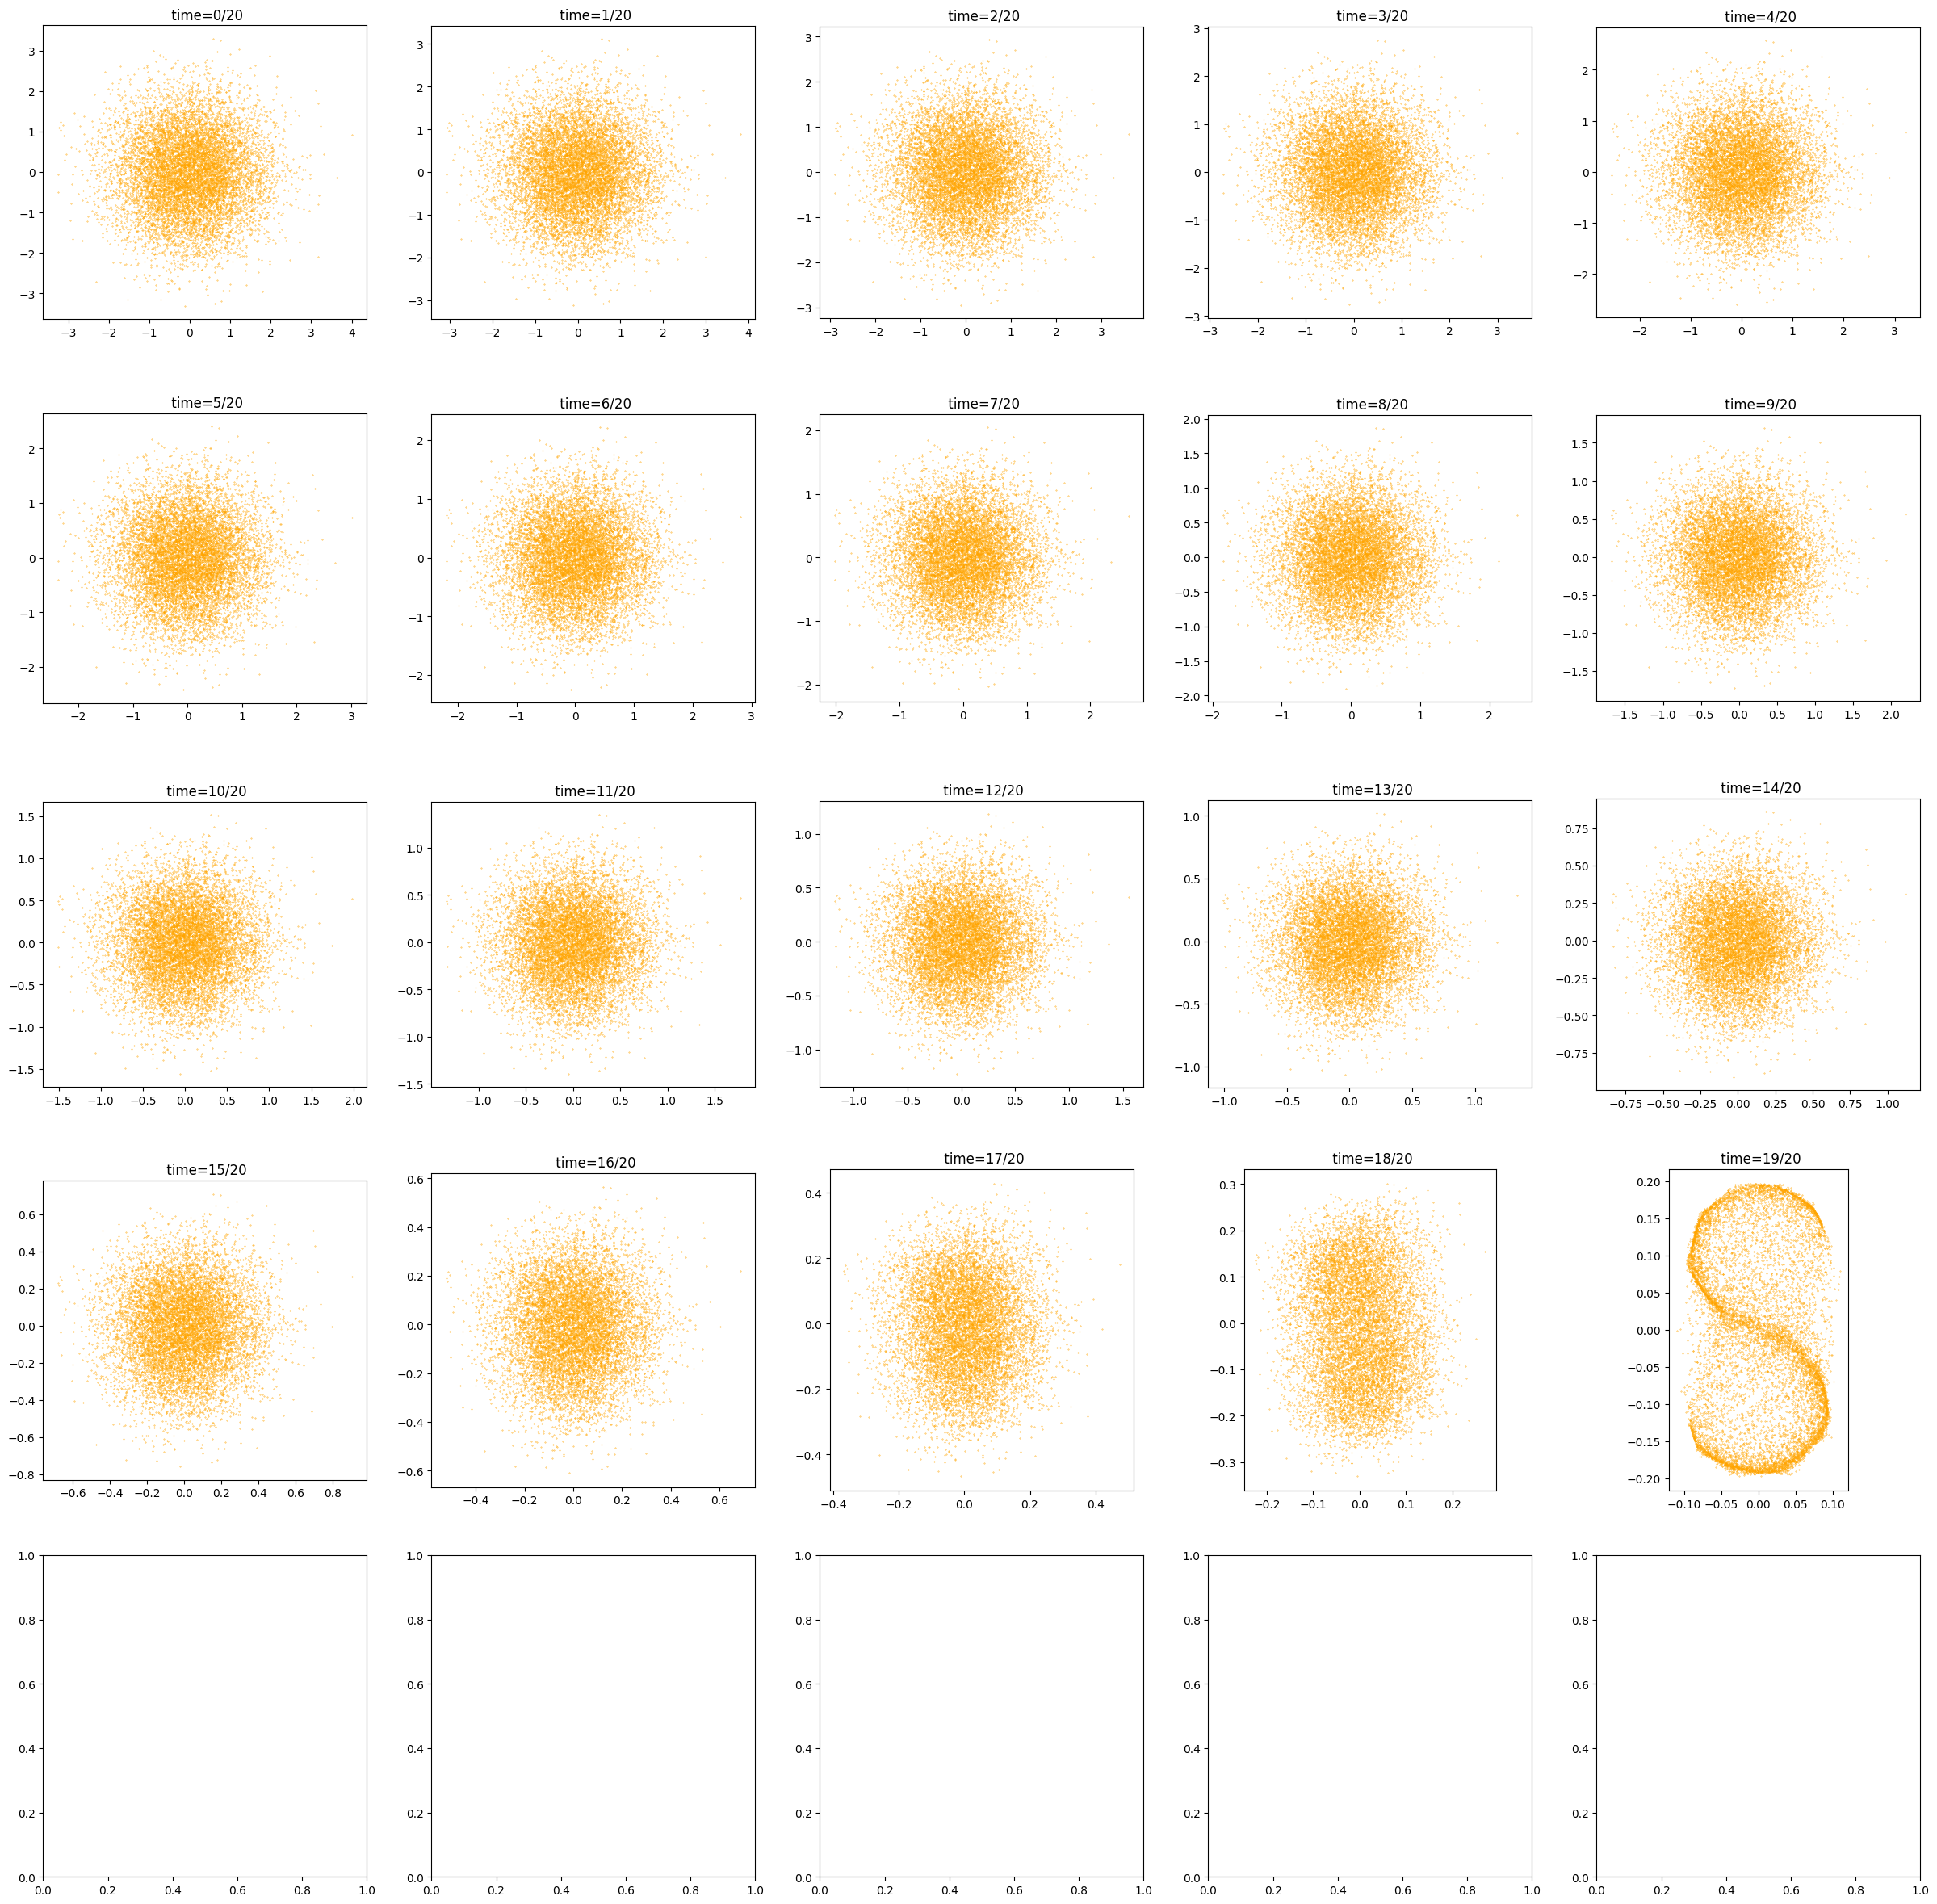

In [29]:
# sampling 
# xt = x_t-1 + v*dt

# eular time scheme
model.eval()
with torch.no_grad():
    n = 20
    t = 0.0
    dt = 1.0/n
    xt = torch.randn(data.shape[0], 2).unsqueeze(0) # t = 0 (1, npts, dim)
    frames = []
    for i in range(n):
        ttensor = torch.tensor([[t]]) # (1, 1)
        volcity = model(xt, ttensor) # (1, npts, dim)
        xt += volcity*torch.tensor([[[dt]]])
        t += dt

        npdata = xt[0].clone().detach().numpy()
        frames.append((npdata, i))

    fig, ax = plt.subplots(len(frames)//5+1, 5, figsize=(30, 30))
    for i, (xt, ti) in enumerate(frames):
        idx = i // 5
        idj = i - idx*5
        ax[idx, idj].scatter(xt[:, 0], xt[:, 1],
                    s=0.1, color="orange")
        ax[idx, idj].set_title(f" time={ti}/{steps}")
        ax[idx, idj].set_aspect('equal')
    plt.show()